# HR Employee Attrition Analysis
**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle)
**Author:** Danish Muhammed

This notebook explores the drivers of employee attrition in a fictional
organization of 1,470 employees, with a particular focus on sales roles,
and builds a simple predictive model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## 1. Load the data

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.shape

(1470, 35)

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

## 2. Clean the data
A few columns are constant across all rows (no analytical value) and are dropped.
`EmployeeNumber` is just an ID field. We also create a numeric `AttritionFlag`
column (1 = left, 0 = stayed) for easier aggregation.

In [5]:
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
df['AttritionFlag'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df.isnull().sum().sum()  # confirm no missing values

np.int64(0)

## 3. Overall attrition rate

In [6]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

**~16.1% of employees in this dataset left the company.**

## 4. Attrition by department

In [7]:
dept_attr = (df.groupby('Department')['AttritionFlag'].mean() * 100).round(1).sort_values(ascending=False)
dept_attr

Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: AttritionFlag, dtype: float64

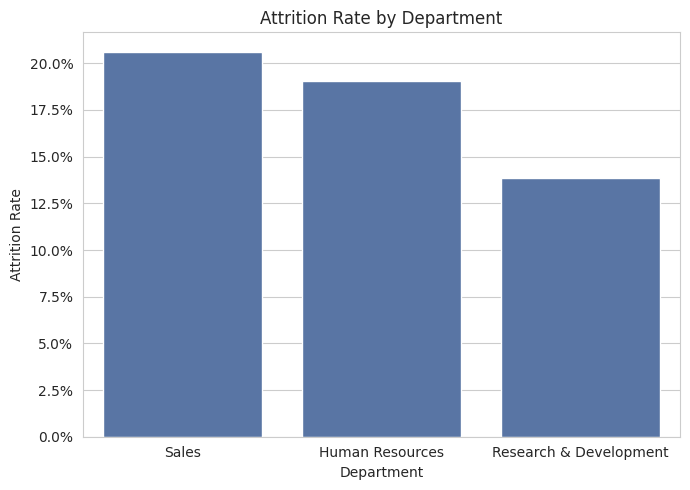

In [8]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Department', y='AttritionFlag', order=dept_attr.index, errorbar=None, color='#4C72B0')
plt.ylabel('Attrition Rate')
plt.title('Attrition Rate by Department')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('charts/01_attrition_by_department.png', dpi=150)
plt.show()

## 5. Attrition by job role
This is the most business-relevant breakdown — it shows exactly which roles
are most at risk.

In [9]:
role_attr = (df.groupby('JobRole')['AttritionFlag'].mean() * 100).round(1).sort_values(ascending=False)
role_attr

JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: AttritionFlag, dtype: float64

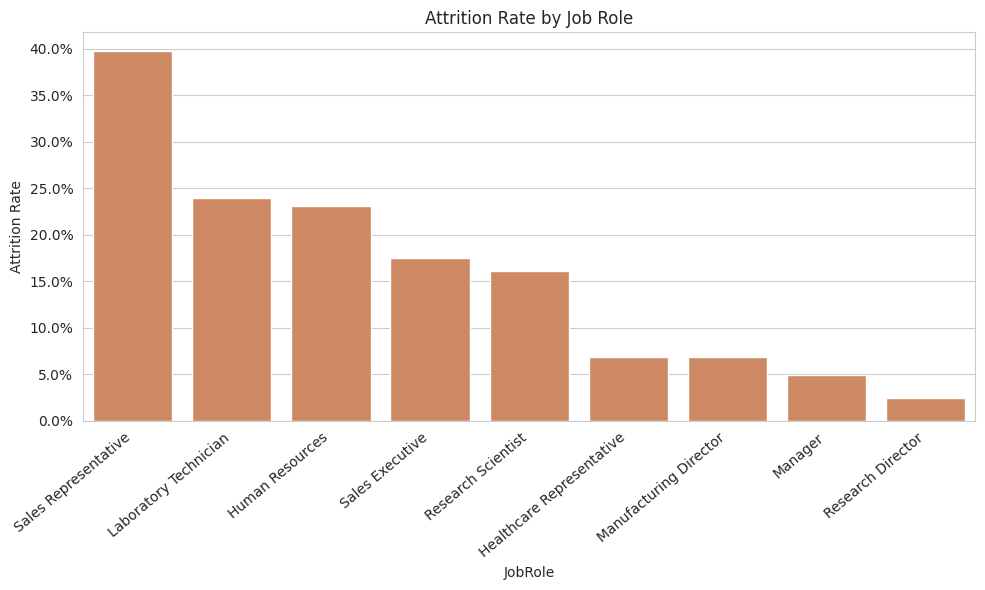

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='JobRole', y='AttritionFlag', order=role_attr.index, errorbar=None, color='#DD8452')
plt.xticks(rotation=40, ha='right')
plt.ylabel('Attrition Rate')
plt.title('Attrition Rate by Job Role')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('charts/02_attrition_by_jobrole.png', dpi=150)
plt.show()

**Sales Representatives have the highest attrition rate of any role (39.8%),**
more than double the company-wide average. Sales Executives sit closer to
the average (17.5%), suggesting the risk is concentrated in the entry-level
sales role specifically rather than sales as a function overall.

## 6. Does overtime drive attrition?

In [11]:
ot_attr = (df.groupby('OverTime')['AttritionFlag'].mean() * 100).round(1)
ot_attr

OverTime
No     10.4
Yes    30.5
Name: AttritionFlag, dtype: float64

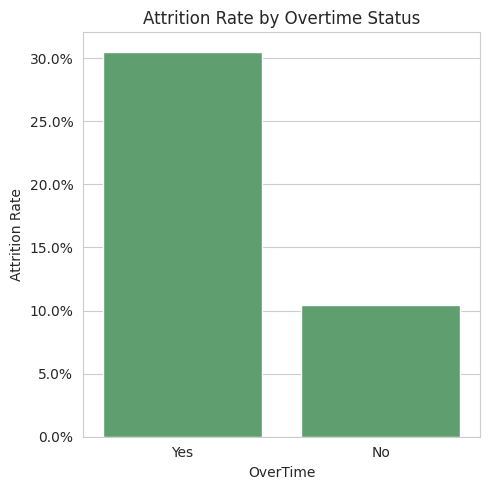

In [12]:
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='OverTime', y='AttritionFlag', errorbar=None, color='#55A868')
plt.ylabel('Attrition Rate')
plt.title('Attrition Rate by Overtime Status')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('charts/04_overtime_vs_attrition.png', dpi=150)
plt.show()

**Employees who work overtime leave nearly 3x more often (30.5%) than those
who don't (10.4%).** This is one of the strongest single drivers in the dataset.

## 7. Income and attrition

In [13]:
df.groupby('Attrition')['MonthlyIncome'].mean().round(0)

Attrition
No     6833.0
Yes    4787.0
Name: MonthlyIncome, dtype: float64

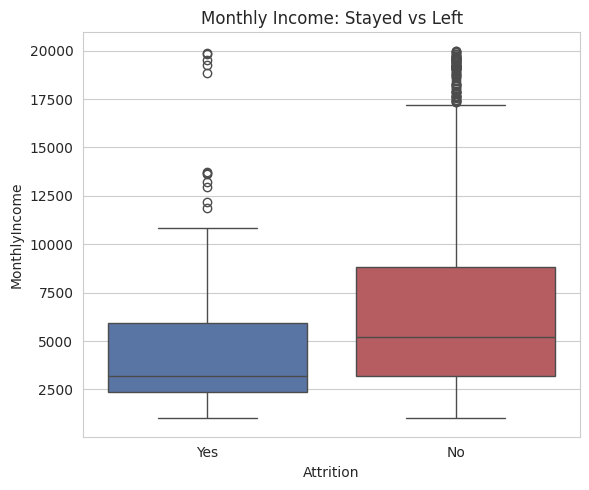

In [14]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette=['#4C72B0','#C44E52'], legend=False)
plt.title('Monthly Income: Stayed vs Left')
plt.tight_layout()
plt.savefig('charts/03_income_vs_attrition.png', dpi=150)
plt.show()

Employees who left earned on average **$4,787/month vs $6,833/month** for
those who stayed — a meaningful gap.

## 8. Business travel frequency

In [15]:
travel_attr = (df.groupby('BusinessTravel')['AttritionFlag'].mean() * 100).round(1).sort_values(ascending=False)
travel_attr

BusinessTravel
Travel_Frequently    24.9
Travel_Rarely        15.0
Non-Travel            8.0
Name: AttritionFlag, dtype: float64

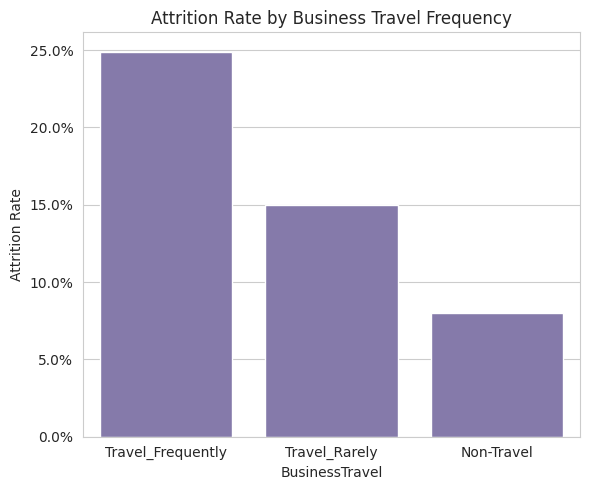

In [16]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='BusinessTravel', y='AttritionFlag', order=travel_attr.index, errorbar=None, color='#8172B2')
plt.ylabel('Attrition Rate')
plt.title('Attrition Rate by Business Travel Frequency')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('charts/05_travel_vs_attrition.png', dpi=150)
plt.show()

## 9. Age, tenure, and satisfaction

In [17]:
summary_tbl = df.groupby('Attrition')[['Age','YearsAtCompany','JobSatisfaction']].mean().round(2)
summary_tbl

,Age,YearsAtCompany,JobSatisfaction
Attrition,,,
No,37.56,7.37,2.78
Yes,33.61,5.13,2.47


Employees who leave are, on average, younger (33.6 vs 37.6 years) and newer
to the company (5.1 vs 7.4 years), with modestly lower job satisfaction
scores (2.47 vs 2.78 on a 1–4 scale).

## 10. Predictive model
A simple logistic regression to see how well these factors predict attrition,
and which factors matter most.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

df_model = df.copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['Attrition', 'AttritionFlag'])
y = df_model['AttritionFlag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, preds), 3))
print(classification_report(y_test, preds))

Accuracy: 0.874
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       247
           1       0.81      0.28      0.41        47

    accuracy                           0.87       294
   macro avg       0.85      0.63      0.67       294
weighted avg       0.87      0.87      0.85       294



/tmp/ipykernel_556/3520880116.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_model.select_dtypes(include='object').columns:
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation 

In [19]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print("Top factors INCREASING attrition risk:")
print(coefs.head(5))
print("\nTop factors DECREASING attrition risk:")
print(coefs.tail(5))

Top factors INCREASING attrition risk:
OverTime              0.889273
MaritalStatus         0.534745
Department            0.301985
PerformanceRating     0.259724
NumCompaniesWorked    0.205576
dtype: float64

Top factors DECREASING attrition risk:
WorkLifeBalance           -0.164115
JobSatisfaction           -0.281934
JobInvolvement            -0.323882
EnvironmentSatisfaction   -0.356632
StockOptionLevel          -0.411061
dtype: float64


The model reaches **87.4% overall accuracy**. It correctly identifies most
employees who stay, but — as expected with an imbalanced dataset (only 16%
leave) — it's more conservative about flagging leavers (28% recall on the
"Yes" class). This is a known limitation to mention honestly in the write-up
rather than a flaw to hide.

The strongest attrition-increasing factor by far is **OverTime**, followed
by marital status and department. The strongest protective factors are
**stock option level, environment satisfaction, and job involvement.**

## 11. Key findings summary

1. Overall attrition rate is **16.1%**.
2. **Sales Representatives** have the highest attrition of any role (**39.8%**),
   over 2x the company average — a specific, addressable retention target.
3. **Overtime is the single strongest driver**: employees working overtime
   leave at **30.5%** vs **10.4%** for those who don't.
4. Employees who leave earn **~30% less** on average ($4,787 vs $6,833/month).
5. Leavers are younger (33.6 vs 37.6) and newer to the company (5.1 vs 7.4 years) —
   attrition risk is highest early in tenure.
6. Frequent business travel roughly **triples** attrition risk compared to
   non-travel roles (24.9% vs 8.0%).

## 12. Recommendations

- **Prioritize retention efforts on Sales Representatives** — review workload,
  overtime exposure, and compensation benchmarking for this role specifically.
- **Audit overtime policy** — investigate whether overtime is being fairly
  compensated or if workload should be redistributed.
- **Strengthen onboarding/early-tenure engagement**, since risk is concentrated
  in the first few years.
- **Review compensation bands** for roles/levels showing income gaps between
  stayers and leavers.